# Imports

In [1]:
import os
from pathlib import Path
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pyfolio as pf
from pyfolio.plotting import plot_rolling_returns,plot_rolling_sharpe
from pyfolio.timeseries import forecast_cone_bootstrap

In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
from backtester import BackTester

In [6]:
data_store=Path("../Prepared_Data_Store")

# BackTesting

## Trading Strategy-I:

### Here we will long the top returns and short the bottom returns values at a particular day as predicted by our Model-8

In [7]:
trading_strategy={
    "strategy":"returns_based",
    "values":{}
}

In [8]:
backtester=BackTester(
    n_longs=20,
    n_shorts=20,
    min_positions=10,
    capital_base=1e6,
    commission_cost=0.00075,
    commission_min_trade_cost=0.01,
    slippage_spread=0.0,
    predictions_file=os.path.join(data_store,"factors.csv"),
    predictions_column_name="Model8_Factors",
    trading_strategy=trading_strategy
)

In [9]:
results=backtester.run_backtesting()

INFO: Model predictions loaded...
INFO: Missing Date Values added in Model Predictions...
INFO: Model Data Loader created...
INFO: Backtesting started for trading strategy-I...
INFO: Backtesting completed...


### Performance analysis using Pyfolio

#### Loading Benchmark Data

In [10]:
benchmark_data=pd.read_csv(
    os.path.join(data_store,"sp500_data.csv"),
    parse_dates=["date"],
    index_col=["date"]
)

In [11]:
benchmark_data=benchmark_data.sp500_returns.tz_localize("UTC")

#### Extracting information from Zipline Results

In [12]:
returns,positions,transactions=pf.utils.extract_rets_pos_txn_from_zipline(results)

#### Plotting Rolling Returns and Sharpe Ratio

In [13]:
LIVE_DATE="2016-02-24"

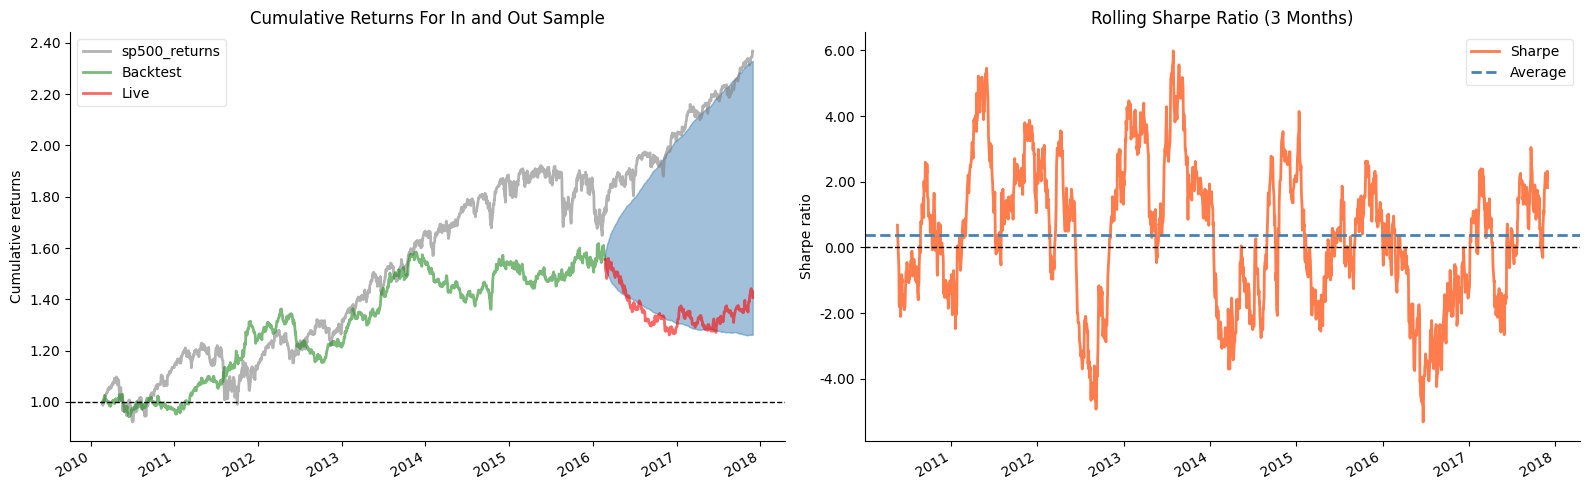

In [14]:
fig,axes=plt.subplots(ncols=2,figsize=(16,5))

plot_rolling_returns(
    returns,
    factor_returns=benchmark_data,
    live_start_date=LIVE_DATE,
    logy=False,
    cone_std=2,
    legend_loc="best",
    volatility_match=False,
    cone_function=forecast_cone_bootstrap,
    ax=axes[0]
)

plot_rolling_sharpe(returns,rolling_window=63,ax=axes[1])

axes[0].set_title("Cumulative Returns For In and Out Sample")
axes[1].set_title("Rolling Sharpe Ratio (3 Months)")

sns.despine()
fig.tight_layout()

#### Full Tear Sheet

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,22.04,2016-01-26,2016-11-30,NaT,NaN
1,15.30,2012-04-12,2012-10-05,2013-02-19,224
2,14.11,2013-11-21,2014-10-13,2015-10-29,506
3,8.37,2010-05-19,2010-06-16,2011-03-14,214
4,6.55,2011-11-29,2011-12-22,2012-03-23,84


Stress Events,mean,min,max
US downgrade/European Debt Crisis,0.23%,-1.87%,3.76%
Fukushima,0.14%,-0.78%,0.96%
EZB IR Event,-0.00%,-0.80%,1.80%
Flash Crash,0.20%,-0.70%,0.85%
Apr14,-0.04%,-1.83%,1.21%
Oct14,0.22%,-1.55%,2.89%
Fall2015,0.06%,-1.83%,1.97%
Recovery,0.03%,-2.56%,3.76%
New Normal,0.01%,-3.18%,2.99%


Top 10 long positions of all time,max
sid,
EXPD,45.08%
PODD,43.01%
NVDA,39.22%
WTW,31.84%
URI,22.73%
FFIV,22.17%
EXC,21.31%
STLD,20.90%
NTAP,20.81%


Top 10 short positions of all time,max
sid,
NVDA,-45.22%
EXPD,-41.12%
PODD,-38.87%
URI,-28.53%
WTW,-26.52%
NFLX,-26.41%
APD,-23.97%
ALB,-21.74%
MGM,-21.02%


Top 10 positions of all time,max
sid,
NVDA,45.22%
EXPD,45.08%
PODD,43.01%
WTW,31.84%
URI,28.53%
NFLX,26.41%
APD,23.97%
FFIV,22.17%
ALB,21.74%


...

PnL stats,All trades,Short trades,Long trades
Total profit,$1059973.18,$-991238.30,$2051211.48
Gross profit,$29155489.30,$13179788.19,$15975701.11
Gross loss,$-28095516.12,$-14171026.50,$-13924489.62
Profit factor,$1.04,$0.93,$1.15
Avg. trade net profit,$13.90,$-26.69,$52.46
Avg. winning trade,$764.71,$738.98,$787.33
Avg. losing trade,$-748.99,$-744.82,$-753.29
Ratio Avg. Win:Avg. Loss,$1.02,$0.99,$1.05
Largest winning trade,$142837.60,$39048.12,$142837.60
Largest losing trade,$-50985.85,$-15938.15,$-50985.85


Duration stats,All trades,Short trades,Long trades
Avg duration,1 days 15:52:15.946604934,1 days 13:36:36.386365472,1 days 18:01:07.300675157
Median duration,1 days 00:00:00,1 days 00:00:00,1 days 00:00:00
Longest duration,398 days 00:00:00,398 days 00:00:00,148 days 01:00:00
Shortest duration,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00


Return stats,All trades,Short trades,Long trades
Avg returns all round_trips,0.00%,-0.00%,0.00%
Avg returns winning,0.06%,0.06%,0.06%
Avg returns losing,-0.06%,-0.06%,-0.06%
Median returns all round_trips,0.00%,-0.00%,0.00%
Median returns winning,0.03%,0.03%,0.04%
Median returns losing,-0.03%,-0.04%,-0.03%
Largest winning trade,9.65%,2.58%,9.65%
Largest losing trade,-3.56%,-1.03%,-3.56%


Symbol stats,A,ACGL,ACN,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,ALB,ALGN,ALL,AMAT,AMD,AME,AMGN,AMP,AMT,AON,AOS,APA,APD,APH,ARE,ATO,AVB,AVGO,AVY,AWK,AXP,AZO,BA,BAC,BAX,BBY,BDX,BEN,BG,BIIB,BK,BLDR,BLK,BMY,BR,BRO,BSX,BXP,C,CAG,CAH,CAT,CB,CCI,CCL,CDNS,CF,CHD,CHRW,CI,CINF,CL,CLX,CME,CMG,CMI,CMS,CNC,CNP,COF,COO,COP,CPB,CPRT,CPT,CRL,CRM,CSCO,CSGP,CSX,CTAS,CTSH,CVS,CVX,D,DAL,DE,DECK,DG,DGX,DHI,DHR,DIS,DLR,DLTR,DOV,DPZ,DRI,DTE,DUK,DVA,DVN,DXCM,EA,EBAY,ECL,ED,EFX,EIX,EL,EMN,EMR,EOG,EQIX,EQR,EQT,ERIE,ES,ESS,ETN,ETR,EW,EXC,EXPD,EXPE,EXR,F,FCX,FDS,FDX,FE,FFIV,FICO,FIS,FITB,FOX,FOXA,FRT,FTNT,GD,GE,GILD,GIS,GLW,GOOGL,GPC,GPN,GRMN,GS,GWW,HAL,HAS,HBAN,HD,HIG,HOLX,HON,HPQ,HRL,HSIC,HST,HSY,HUM,IBM,ICE,IDXX,IEX,IFF,INCY,INTU,IP,IPG,IR,IRM,ISRG,IT,ITW,IVZ,JBHT,JBL,JCI,JKHY,JNJ,JPM,K,KEY,KIM,KLAC,KMB,KMX,KO,KR,L,LDOS,LEN,LH,LII,LKQ,LLY,LMT,LNT,LRCX,LUV,LVS,LYV,MA,MAA,MAR,MAS,MCD,MCHP,MCK,MCO,MDLZ,MDT,MET,MGM,MHK,MKC,MKTX,MLM,MMC,MNST,MO,MOH,MOS,MPWR,MRK,MS,MSCI,MSFT,MSI,MTB,MTD,MU,NDAQ,NDSN,NEE,NEM,NFLX,NI,NKE,NOC,NRG,NSC,NTAP,NTRS,NUE,NVDA,NVR,O,ODFL,OKE,OMC,ORCL,ORLY,OXY,PAYX,PCAR,PCG,PEG,PEP,PFE,PFG,PG,PGR,PH,PHM,PKG,PLD,PM,PNC,PNR,PNW,PODD,POOL,PPG,PPL,PRU,PSA,PWR,RCL,REG,REGN,RF,RJF,RL,RMD,ROK,ROL,ROP,ROST,RSG,SBAC,SBUX,SCHW,SHW,SJM,SLB,SMCI,SNA,SNPS,SO,SPG,SRE,STE,STLD,STT,STX,STZ,SWK,SWKS,SYK,SYY,T,TAP,TDG,TDY,TECH,TEL,TER,TGT,TJX,TMO,TMUS,TRMB,TROW,TSCO,TSN,TTWO,TXN,TXT,TYL,UAL,UDR,UHS,ULTA,UNH,UNP,UPS,URI,USB,V,VLO,VMC,VRSK,VRSN,VRTX,VTR,VZ,WAB,WAT,WBA,WDC,WEC,WFC,WM,WMB,WMT,WRB,WSM,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
Avg returns all round_trips,0.01%,0.00%,-0.00%,0.01%,0.01%,0.00%,-0.01%,-0.00%,-0.00%,-0.00%,-0.01%,-0.02%,0.01%,0.00%,-0.01%,-0.01%,-0.01%,-0.00%,-0.00%,0.00%,-0.01%,0.03%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,0.01%,-0.01%,-0.00%,-0.01%,0.01%,0.01%,0.00%,0.00%,0.00%,-0.00%,0.02%,-0.00%,0.01%,-0.00%,0.01%,0.01%,0.00%,0.00%,0.02%,0.01%,-0.01%,-0.01%,-0.00%,0.01%,-0.01%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.01%,0.00%,0.01%,0.00%,-0.00%,0.01%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,0.01%,-0.00%,0.00%,-0.00%,0.01%,-0.01%,-0.00%,0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,0.01%,0.00%,0.00%,0.01%,-0.01%,0.00%,0.00%,-0.00%,-0.00%,-0.01%,0.00%,0.01%,0.00%,0.01%,0.01%,-0.00%,0.00%,0.01%,0.00%,-0.00%,-0.01%,-0.01%,-0.00%,-0.02%,-0.00%,0.00%,0.00%,0.01%,-0.00%,0.00%,0.00%,-0.01%,-0.00%,0.01%,0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.01%,-0.00%,-0.03%,0.00%,-0.00%,0.01%,-0.00%,-0.01%,-0.00%,0.00%,-0.01%,-0.01%,-0.01%,-0.00%,-0.01%,0.01%,0.01%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,0.00%,-0.01%,0.01%,0.01%,0.01%,0.02%,0.01%,-0.00%,-0.01%,0.01%,0.00%,-0.00%,0.01%,0.01%,0.00%,0.00%,-0.00%,0.01%,-0.01%,0.00%,-0.01%,-0.01%,-0.00%,0.01%,0.00%,0.00%,-0.00%,-0.01%,0.00%,-0.01%,-0.00%,-0.00%,-0.00%,0.00%,0.01%,-0.00%,-0.00%,-0.00%,-0.01%,0.00%,0.01%,-0.00%,0.01%,0.01%,0.01%,0.00%,0.00%,0.00%,0.00%,-0.01%,-0.01%,0.00%,0.00%,-0.01%,0.10%,0.00%,0.00%,0.01%,0.01%,-0.01%,0.00%,0.01%,-0.01%,0.00%,0.00%,0.00%,0.00%,0.00%,0.01%,0.02%,0.00%,0.00%,0.00%,-0.00%,0.01%,-0.01%,-0.02%,-0.00%,0.01%,-0.00%,-0.01%,-0.00%,0.01%,0.01%,-0.00%,0.00%,0.00%,0.01%,0.00%,0.02%,-0.00%,0.01%,0.01%,0.00%,-0.00%,0.00%,0.01%,0.00%,-0.00%,0.00%,0.01%,-0.00%,0.01%,0.00%,-0.01%,-0.00%,-0.01%,0.01%,0.00%,0.02%,0.01%,0.00%,-0.00%,0.00%,0.00%,0.00%,0.00%,-0.01%,-0.01%,-0.00%,-0.00%,0.00%,0.00%,0.00%,0.02%,-0.01%,-0.00%,-0.01%,0.00%,-0.01%,-0.00%,0.00%,0.01%,0.00%,-0.01%,0.00%,0.00%,0.01%,-0.00%,-0.00%,0.00%,0.00%,-0.01%,-0.00%,0.01%,-0.00%,0.01%,0.01%,-0.01%,-0.00%,0.01%,0.01%,-0.00%,0.00%,-0.00%,0.01%,0.01%,0.00%,0.00%,-0.01%,-0.00%,0.01%,0.00%,0.00%,0.01%,0.00%,0.00%,0.00%,-0.00%,0.02%,0.01%,-0.01%,0.00%,0.00%,-0.00%,-0.00%,0.01%,0.01%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.01%,0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.01%,0.01%,0.01%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.01%,0.01%,-0.00%,0.02%,0.01%,-0.00%,-0.01%,-0.01%,0.01%,0.00%,-0.01%,-0.01%,-0.00%,0.01%,0.01%,-0.01%,-0.00%,-0.00%,0.01%,0.00%,-0.00%,0.00%,-0.00%,0.00%,0.00%,-0.00%,0.01%,0.01%,-0.00%,0.00%,0.00%,0.01%,-0.00%
Avg returns winning,0.0

Profitability (PnL / PnL total) per name,
symbol,
LDOS,36.20%
NVDA,9.60%
BLDR,7.60%
BBY,7.11%
STX,4.61%
MNST,4.53%
RL,4.46%
GIS,4.38%
TAP,4.30%


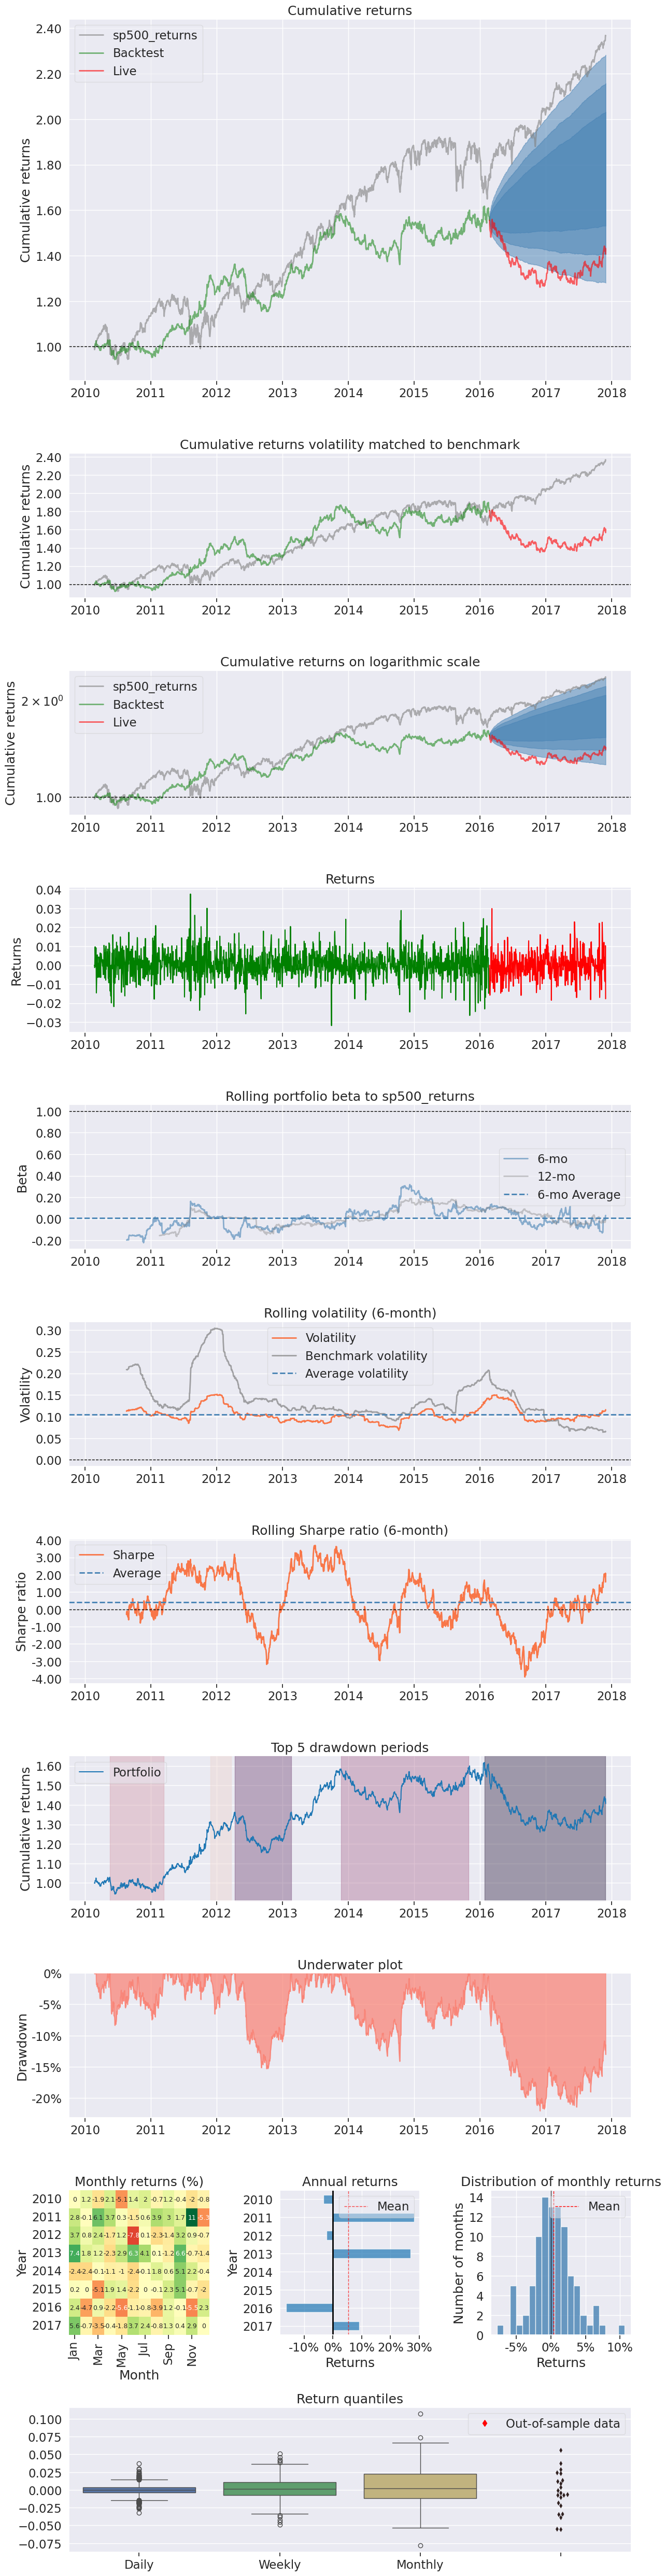

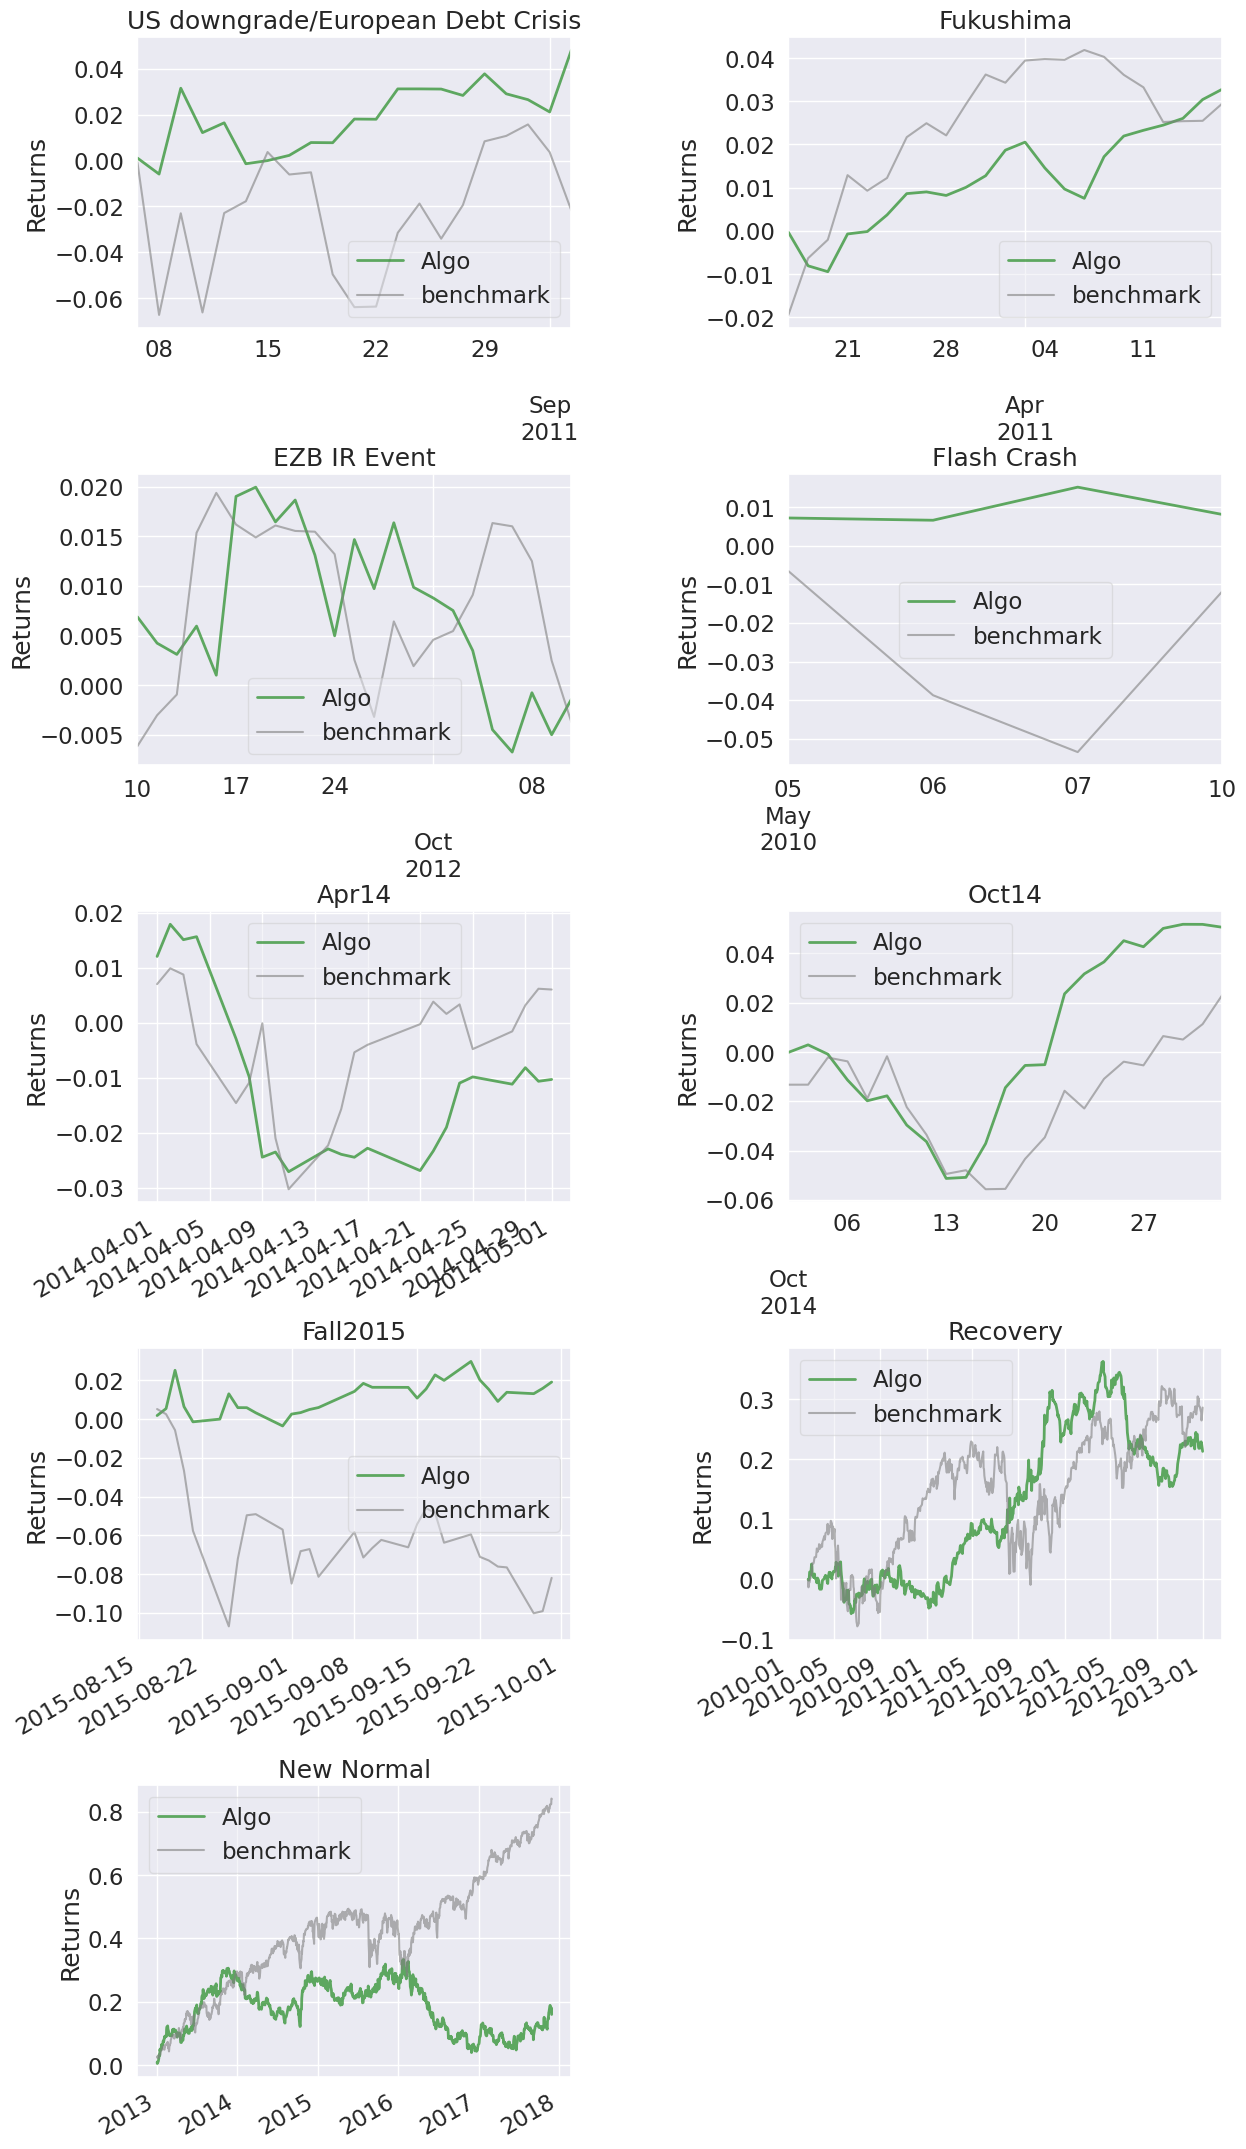

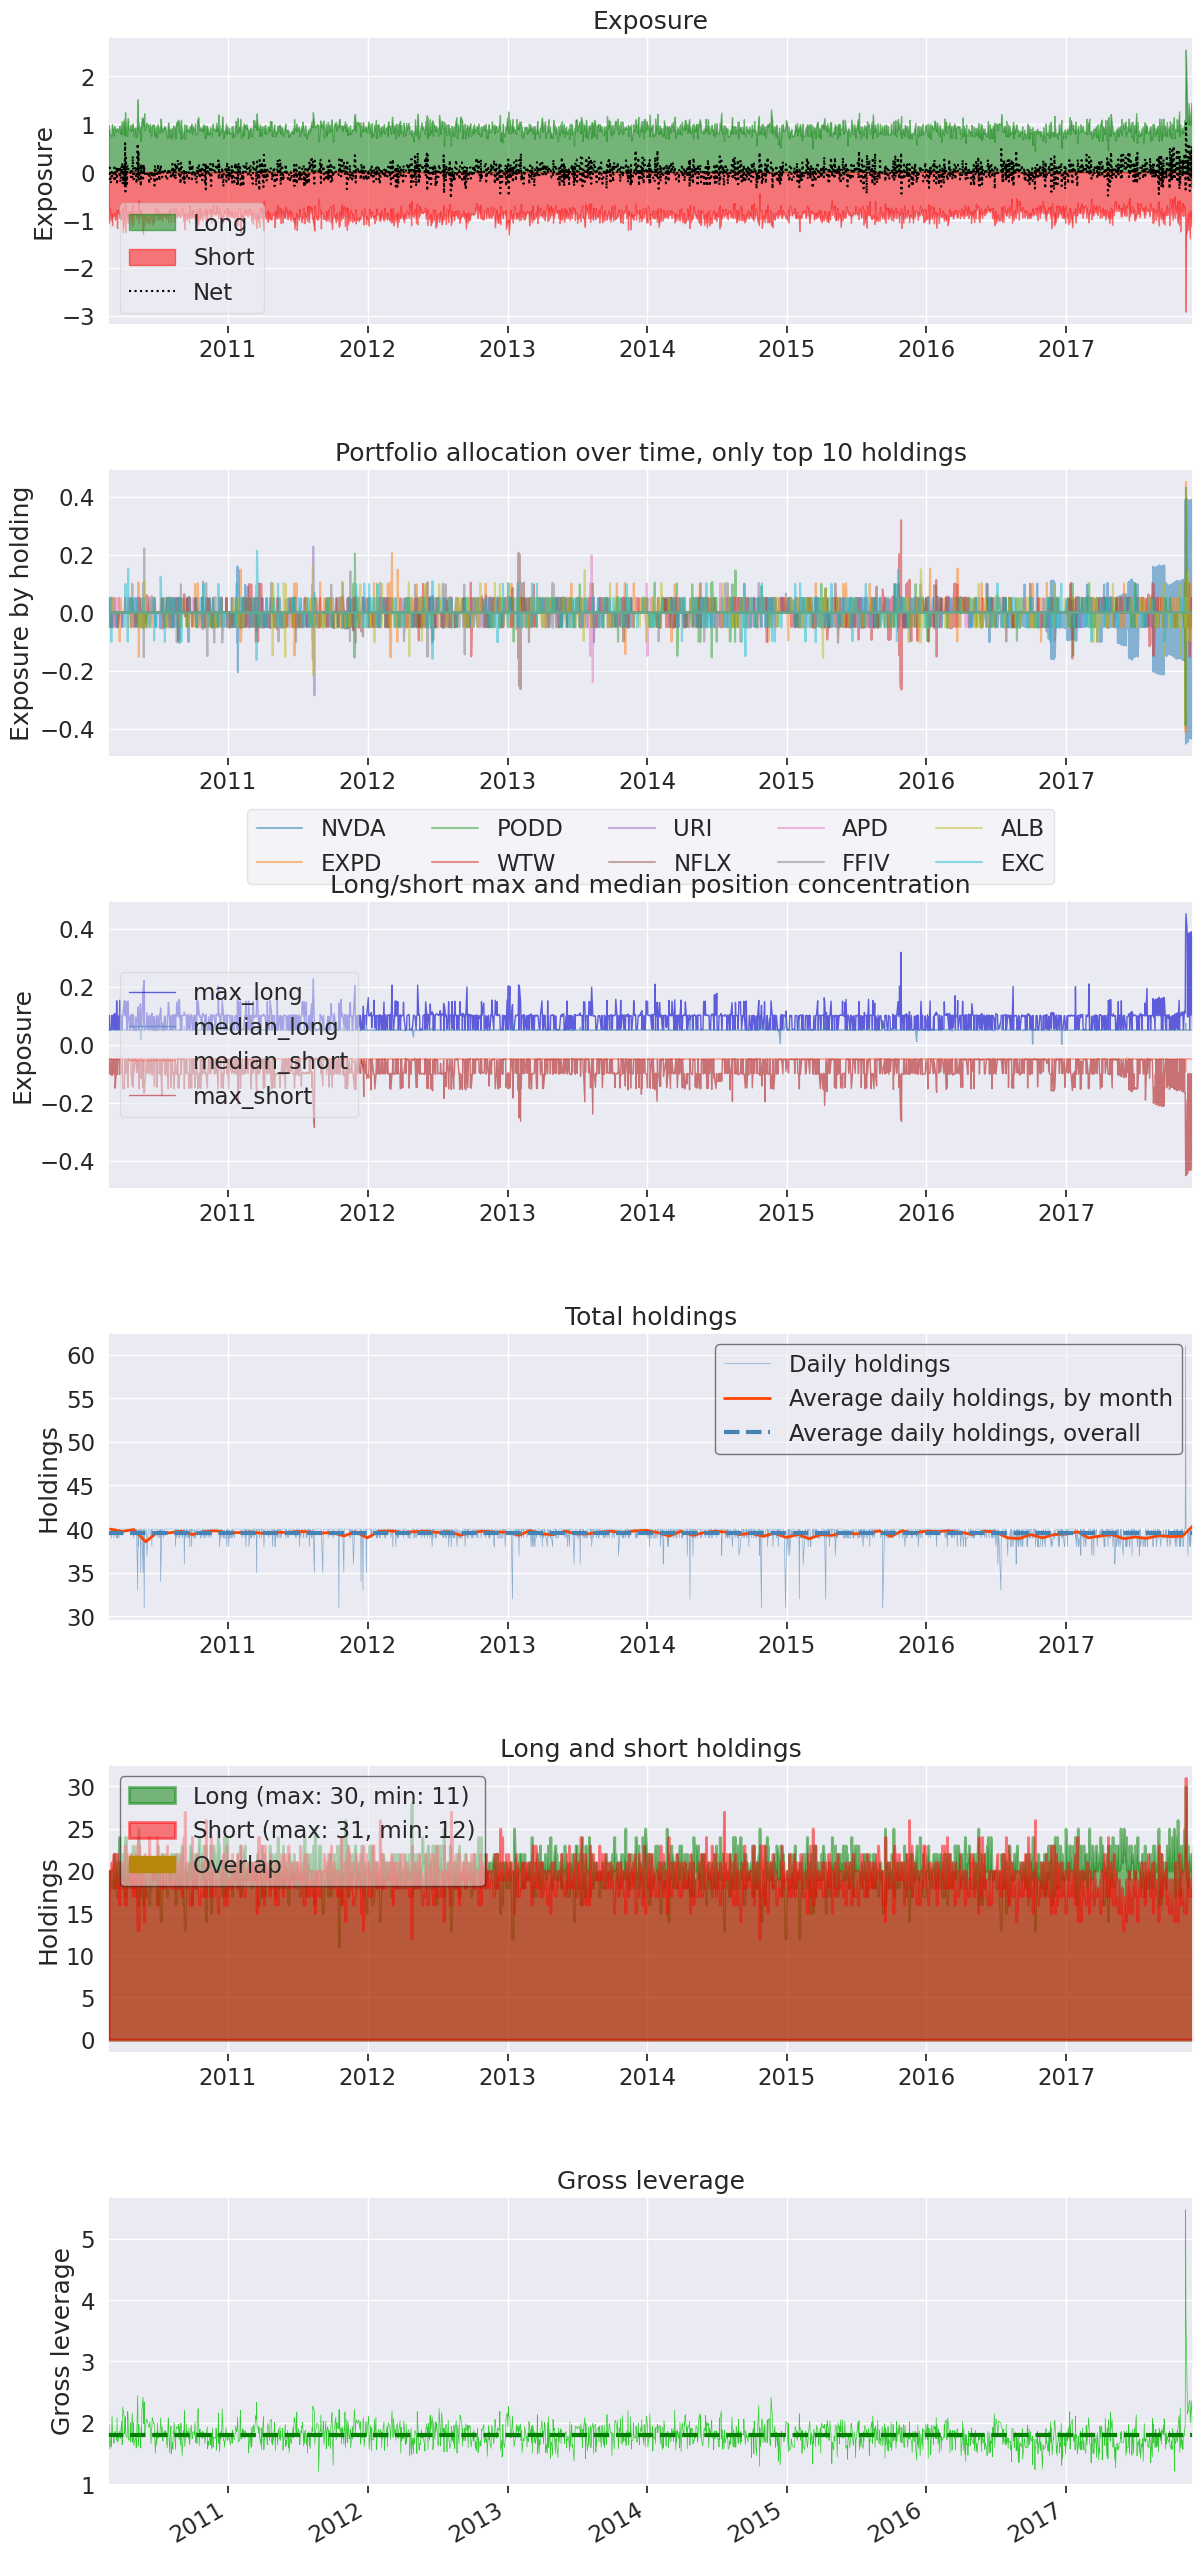

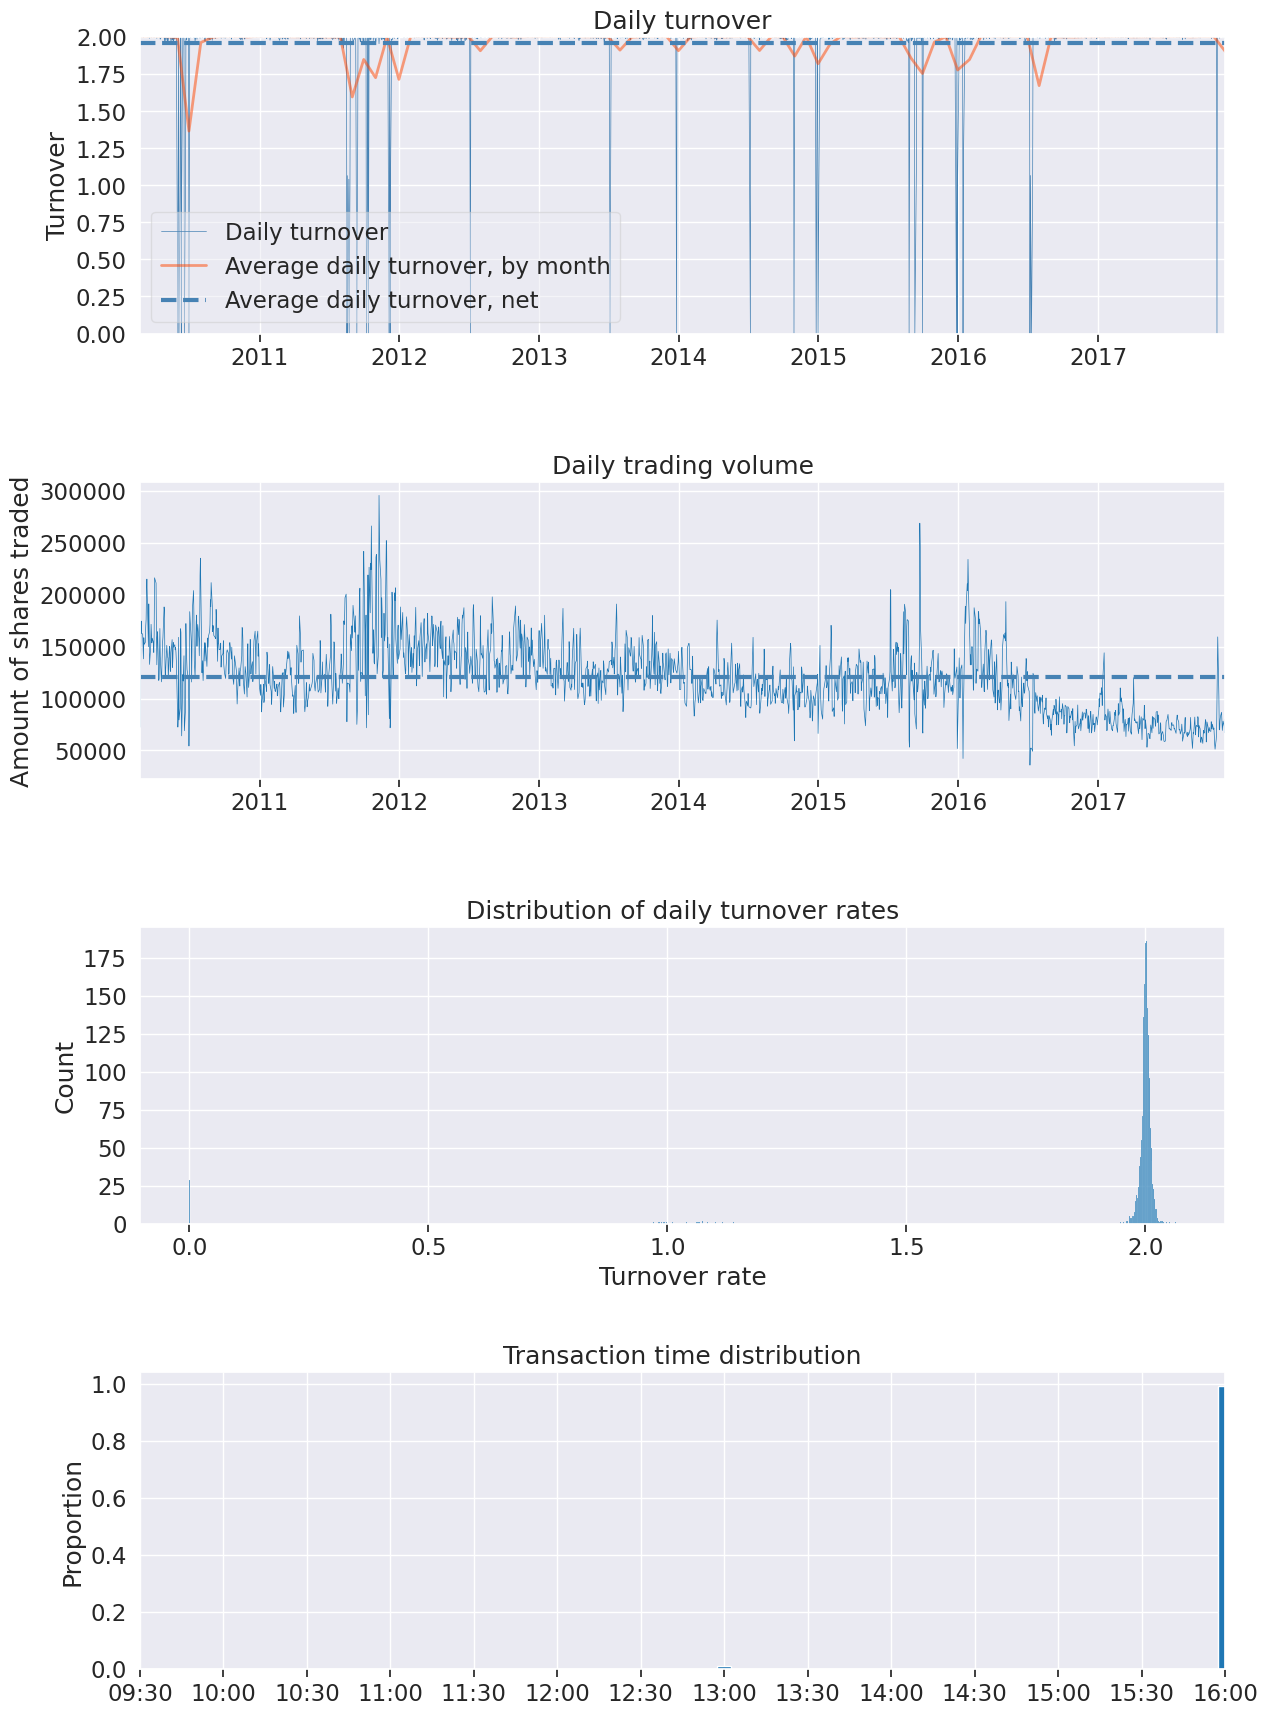

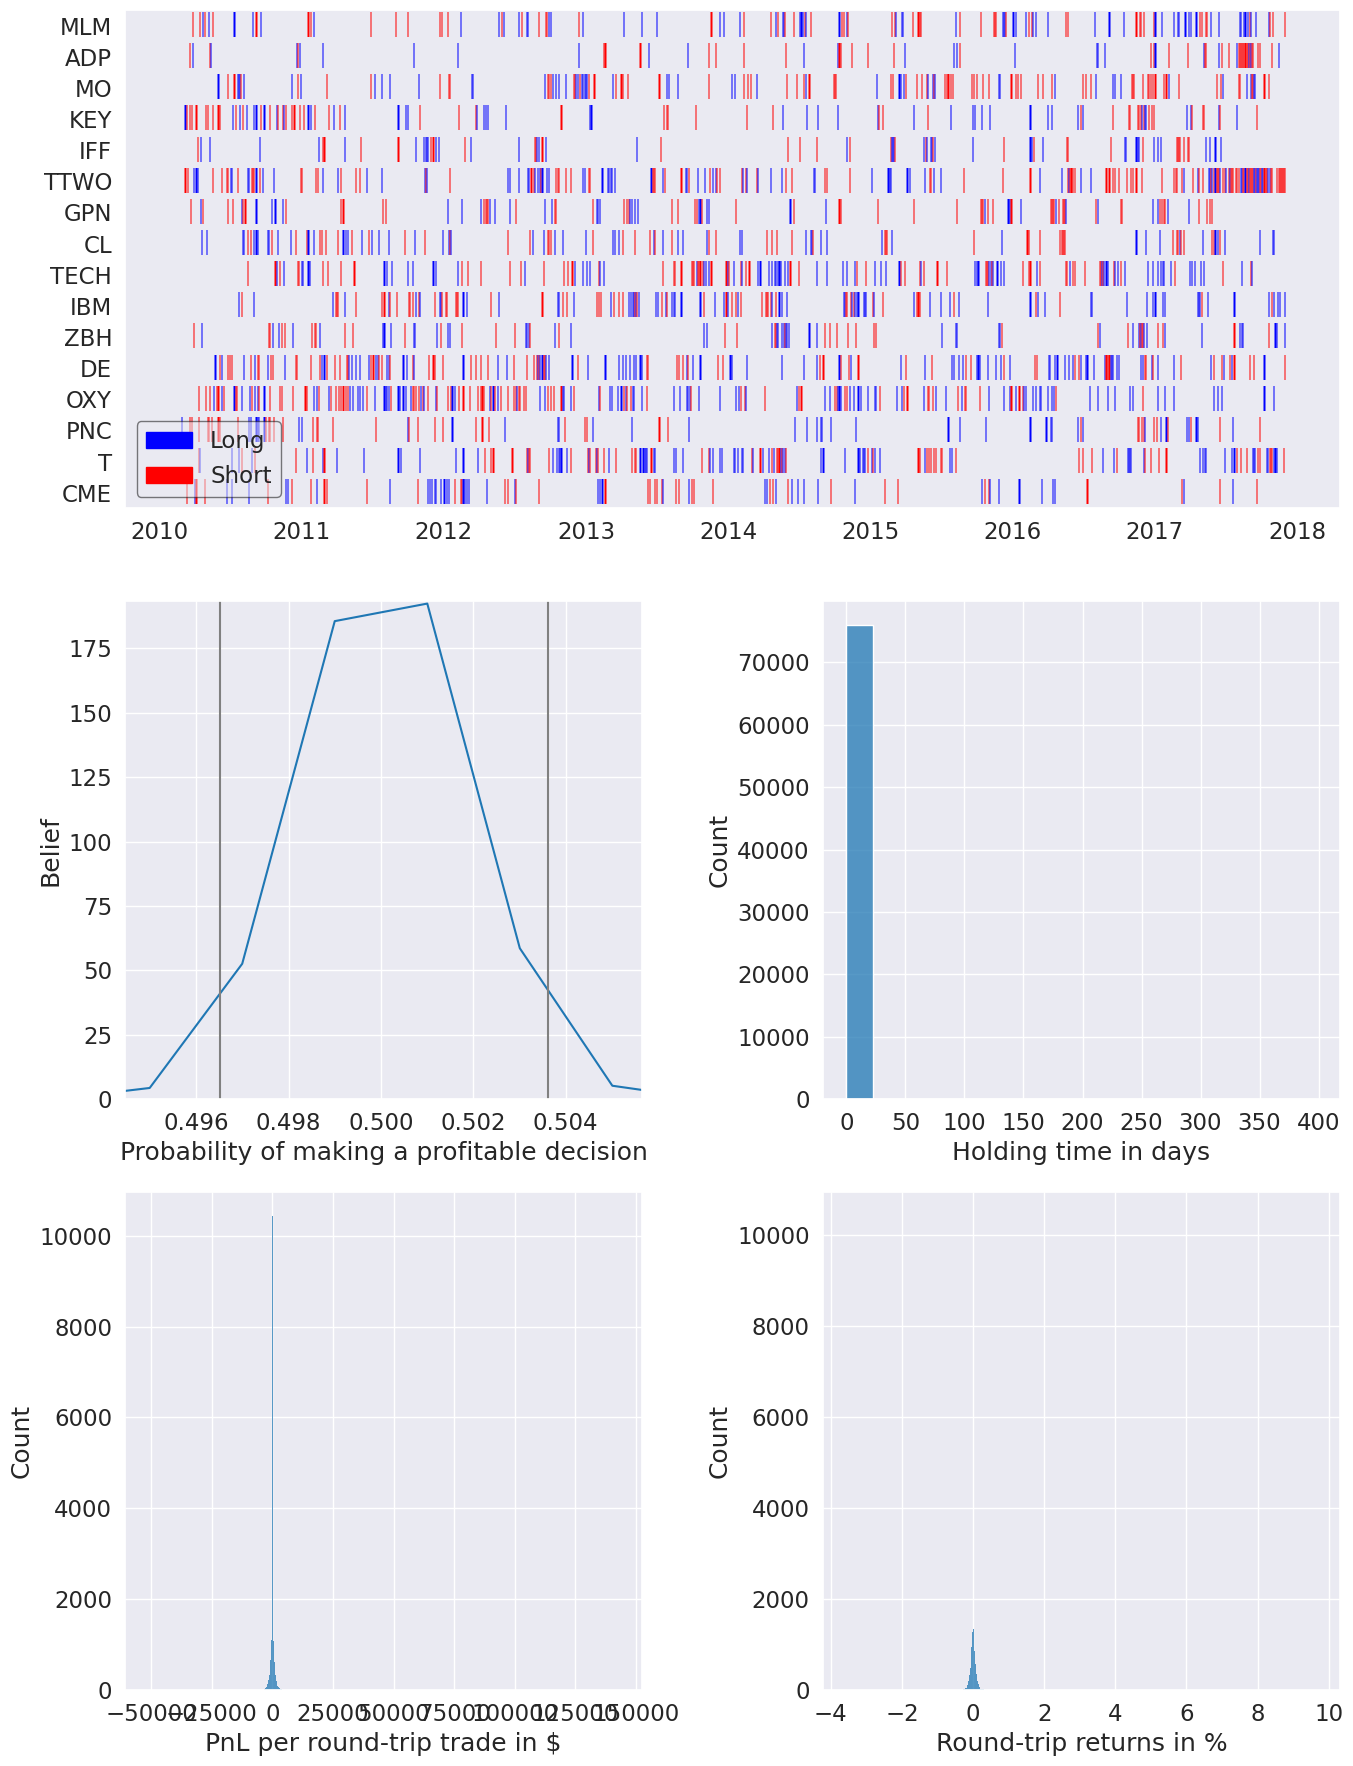

In [15]:
pf.create_full_tear_sheet(
    returns,
    positions=positions,
    transactions=transactions,
    benchmark_rets=benchmark_data,
    live_start_date=LIVE_DATE,
    round_trips=True
)

## Trading Strategy-II:

### As per the Signal Evaluation of the Model-8 Factors, we will long and short predictions in quantiles 5 and 4 respectively.

In [16]:
trading_strategy={
    "strategy":"quantile_based",
    "values":{
        "quantile_long":5,
        "quantile_short":4
}

}

In [17]:
backtester=BackTester(
    n_longs=20,
    n_shorts=20,
    min_positions=10,
    capital_base=1e6,
    commission_cost=0.00075,
    commission_min_trade_cost=0.01,
    slippage_spread=0.0,
    predictions_file=os.path.join(data_store,"factors.csv"),
    predictions_column_name="Model8_Factors",
    trading_strategy=trading_strategy
)

In [18]:
results=backtester.run_backtesting()

INFO: Model predictions loaded...
INFO: Missing Date Values added in Model Predictions...
INFO: Model Data Loader created...
INFO: Backtesting started for trading strategy-II...
INFO: Backtesting completed...


### Performance analysis using Pyfolio

#### Extracting information from Zipline Results

In [19]:
returns,positions,transactions=pf.utils.extract_rets_pos_txn_from_zipline(results)

#### Plotting Rolling Returns and Sharpe Ratio

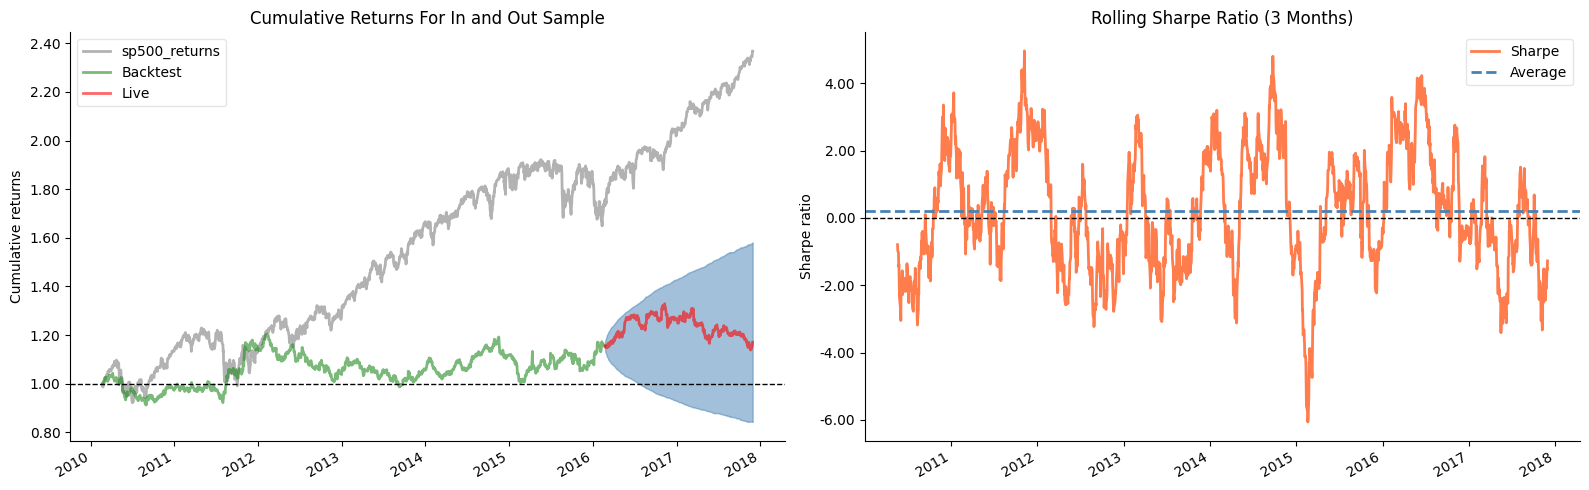

In [20]:
fig,axes=plt.subplots(ncols=2,figsize=(16,5))

plot_rolling_returns(
    returns,
    factor_returns=benchmark_data,
    live_start_date=LIVE_DATE,
    logy=False,
    cone_std=2,
    legend_loc="best",
    volatility_match=False,
    cone_function=forecast_cone_bootstrap,
    ax=axes[0]
)

plot_rolling_sharpe(returns,rolling_window=63,ax=axes[1])

axes[0].set_title("Cumulative Returns For In and Out Sample")
axes[1].set_title("Rolling Sharpe Ratio (3 Months)")

sns.despine()
fig.tight_layout()

#### Full Tear Sheet

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,18.03,2012-02-08,2013-09-09,2016-04-13,1091
1,14.33,2016-11-10,2017-11-20,NaT,NaN
2,12.52,2010-04-07,2010-08-31,2011-08-25,362
3,4.91,2016-06-30,2016-08-17,2016-08-24,40
4,3.91,2011-09-15,2011-10-05,2011-10-28,32


Stress Events,mean,min,max
US downgrade/European Debt Crisis,0.48%,-1.06%,3.13%
Fukushima,-0.02%,-1.67%,1.93%
EZB IR Event,0.03%,-1.56%,1.94%
Flash Crash,0.26%,-0.41%,1.08%
Apr14,0.10%,-1.35%,1.17%
Oct14,0.10%,-0.80%,1.83%
Fall2015,0.04%,-0.98%,2.18%
Recovery,0.01%,-2.87%,3.29%
New Normal,0.01%,-4.87%,6.60%


Top 10 long positions of all time,max
sid,
BEN,51.67%
AOS,40.43%
COP,39.75%
CSX,39.04%
DAL,38.99%
BK,38.66%
DGX,35.90%
AVB,34.24%
AMP,32.87%


Top 10 short positions of all time,max
sid,
BEN,-56.13%
CVS,-40.39%
AMP,-37.91%
AXP,-35.99%
C,-35.78%
BK,-35.57%
COP,-34.87%
AOS,-34.82%
ACGL,-34.50%


Top 10 positions of all time,max
sid,
BEN,56.13%
AOS,40.43%
CVS,40.39%
COP,39.75%
CSX,39.04%
DAL,38.99%
BK,38.66%
AMP,37.91%
AXP,35.99%


...

PnL stats,All trades,Short trades,Long trades
Total profit,$508155.51,$-1493355.80,$2001511.31
Gross profit,$27508351.33,$12672593.23,$14835758.10
Gross loss,$-27000195.82,$-14165949.03,$-12834246.79
Profit factor,$1.02,$0.89,$1.16
Avg. trade net profit,$6.53,$-37.85,$52.10
Avg. winning trade,$714.48,$684.45,$742.31
Avg. losing trade,$-698.56,$-688.20,$-710.37
Ratio Avg. Win:Avg. Loss,$1.02,$0.99,$1.04
Largest winning trade,$71988.05,$47133.19,$71988.05
Largest losing trade,$-63668.62,$-46694.32,$-63668.62


Duration stats,All trades,Short trades,Long trades
Avg duration,1 days 14:28:39.531855599,1 days 12:49:27.421850443,1 days 16:10:31.688965822
Median duration,1 days 00:00:00,1 days 00:00:00,1 days 00:00:00
Longest duration,69 days 00:00:00,51 days 00:00:00,69 days 00:00:00
Shortest duration,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00


Return stats,All trades,Short trades,Long trades
Avg returns all round_trips,0.00%,-0.00%,0.00%
Avg returns winning,0.07%,0.06%,0.07%
Avg returns losing,-0.06%,-0.06%,-0.07%
Median returns all round_trips,0.00%,-0.00%,0.00%
Median returns winning,0.04%,0.04%,0.04%
Median returns losing,-0.04%,-0.04%,-0.04%
Largest winning trade,6.77%,4.35%,6.77%
Largest losing trade,-4.96%,-4.12%,-4.96%


Symbol stats,A,ACGL,ACN,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,ALB,ALGN,ALL,AMAT,AMD,AME,AMGN,AMP,AMT,AON,AOS,APA,APD,APH,ARE,ATO,AVB,AVGO,AVY,AWK,AXP,AZO,BA,BAC,BAX,BBY,BDX,BEN,BG,BIIB,BK,BLDR,BLK,BMY,BR,BRO,BSX,BXP,C,CAG,CAH,CAT,CB,CCI,CCL,CDNS,CF,CHD,CHRW,CI,CINF,CL,CLX,CME,CMG,CMI,CMS,CNC,CNP,COF,COO,COP,CPB,CPRT,CPT,CRL,CRM,CSCO,CSGP,CSX,CTAS,CTSH,CVS,CVX,D,DAL,DE,DECK,DG,DGX,DHI,DHR,DIS,DLR,DLTR,DOV,DPZ,DRI,DTE,DUK,DVA,DVN,DXCM,EA,EBAY,ECL,ED,EFX,EIX,EL,EMN,EMR,EOG,EQIX,EQR,EQT,ERIE,ES,ESS,ETN,ETR,EW,EXC,EXPD,EXPE,EXR,F,FCX,FDS,FDX,FE,FFIV,FICO,FIS,FITB,FOX,FOXA,FRT,FTNT,GD,GE,GILD,GIS,GLW,GOOGL,GPC,GRMN,GS,GWW,HAL,HAS,HBAN,HON
Avg returns all round_trips,0.01%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.01%,0.00%,-0.00%,-0.01%,-0.00%,0.00%,-0.00%,0.00%,0.00%,0.01%,-0.00%,0.00%,0.00%,0.01%,-0.00%,0.00%,-0.01%,0.00%,0.01%,-0.01%,0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.01%,-0.00%,-0.00%,0.01%,-0.01%,0.01%,0.01%,0.01%,-0.00%,-0.01%,-0.00%,0.00%,0.01%,0.01%,0.01%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,0.01%,-0.00%,0.00%,-0.01%,0.00%,-0.00%,0.00%,-0.01%,-0.00%,0.00%,0.00%,0.00%,-0.00%,0.00%,0.00%,-0.00%,0.00%,0.01%,-0.00%,-0.00%,-0.00%,0.00%,0.01%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.01%,0.00%,-0.01%,0.01%,0.01%,0.00%,-0.00%,0.00%,0.00%,0.00%,-0.00%,0.00%,0.01%,-0.00%,-0.00%,-0.01%,-0.00%,-0.01%,0.01%,-0.00%,-0.01%,-0.00%,0.00%,-0.01%,-0.00%,-0.00%,-0.00%,-0.00%,-0.01%,0.01%,-0.01%,0.00%,-0.01%,0.01%,0.01%,0.00%,0.00%,0.01%,-0.00%,0.01%,-0.00%,-0.01%,0.01%,-0.01%,-0.01%,0.00%,0.00%,0.00%,0.03%,0.01%,0.01%,-0.07%,-0.01%,-0.01%,0.01%,-0.01%,0.01%,-0.00%,0.04%,0.02%,-0.00%,0.04%,-0.02%,0.02%,-0.03%,0.03%,-0.02%,0.03%,0.01%,-0.00%,-0.03%,0.04%,-0.03%,-0.08%,-0.03%,0.24%,0.15%
Avg returns winning,0.08%,0.05%,0.06%,0.07%,0.07%,0.05%,0.09%,0.06%,0.04%,0.07%,0.05%,0.06%,0.06%,0.05%,0.08%,0.10%,0.04%,0.08%,0.14%,0.08%,0.06%,0.07%,0.05%,0.06%,0.08%,0.07%,0.06%,0.06%,0.05%,0.05%,0.05%,0.10%,0.06%,0.04%,0.06%,0.07%,0.05%,0.09%,0.06%,0.10%,0.04%,0.06%,0.06%,0.08%,0.07%,0.18%,0.08%,0.06%,0.05%,0.05%,0.08%,0.05%,0.08%,0.04%,0.06%,0.06%,0.05%,0.05%,0.06%,0.07%,0.09%,0.08%,0.06%,0.07%,0.05%,0.04%,0.04%,0.06%,0.09%,0.08%,0.05%,0.09%,0.05%,0.07%,0.06%,0.07%,0.04%,0.04%,0.05%,0.07%,0.08%,0.06%,0.06%,0.08%,0.06%,0.06%,0.04%,0.05%,0.04%,0.11%,0.06%,0.10%,0.06%,0.05%,0.07%,0.06%,0.05%,0.05%,0.08%,0.06%,0.06%,0.06%,0.04%,0.03%,0.05%,0.07%,0.09%,0.08%,0.07%,0.05%,0.03%,0.06%,0.03%,0.06%,0.06%,0.06%,0.08%,0.07%,0.04%,0.08%,0.05%,0.03%,0.05%,0.06%,0.03%,0.08%,0.07%,0.06%,0.08%,0.07%,0.05%,0.10%,0.04%,0.03%,0.05%,0.06%,0.14%,0.05%,0.08%,0.05%,0.09%,0.06%,0.05%,0.06%,NaN,0.03%,0.01%,0.03%,0.03%,0.04%,NaN,0.15%,0.02%,NaN,NaN,0.24%,0.15%
Avg returns losing,-0.07%,-0.04%,-0.05%,-0.07%,-0.06%,-0.04%,-0.08%,-0.05%,-0.05%,-0.08%,-0.05%,-0.07%,-0.06%,-0.05%,-0.07%,-0.09%,-0.05%,-0.07%,-0.13%,-0.07%,-0.06%,-0.06%,-0.06%,-0.04%,-0.07%,-0.08%,-0.05%,-0.05%,-0.06%,-0.05%,-0.06%,-0.10%,-0.07%,-0.05%,-0.06%,-0.06%,-0.07%,-0.08%,-0.05%,-0.09%,-0.05%,-0.07%,-0.06%,-0.07%,-0.06%,-0.15%,-0.06%,-0.05%,-0.06%,-0.05%,-0.08%,-0.05%,-0.07%,-0.05%,-0.06%,-0.07%,-0.04%,-0.05%,-0.06%,-0.08%,-0.10%,-0.07%,-0.05%,-0.06%,-0.06%,-0.04%,-0.04%,-0.06%,-0.09%,-0.07%,-0.05%,-0.09%,-0.05%,-0.07%,-0.06%,-0.07%,-0.04%,-0.05%,-0.05%,-0.06%,-0.09%,-0.05%,-0.07%,-0.07%,-0.04%,-0.06%,-0.05%,-0.05%,-0.04%,-0.09%,-0.06%,-0.10%,-0.06%,-0.05%,-0.08%,-0.08%,-0.05%,-0.06%,-0.06%,-0.06%,-0.07%,-0.06%,-0.04%,-0.04%,-0.04%,-0.08%,-0.08%,-0.08%,-0.09%,-0.04%,-0.04%,-0.05%,-0.04%,-0.05%,-0.06%,-0.06%,-0.07%,-0.05%,-0.05%,-0.07%,-0.04%,-0.05%,-0.05%,-0.06%,-0.04%,-0.07%,-0.04%,-0.04%,-0.05%,-0.05%,-0.05%,-0.17%,-0.05%,-0.05%,-0.02%,-0.09%,-0.08%,-0.06%,-0.04%,-0.02%,-0.07%,-0.01%,-0.11%,-0.04%,-0.03%,NaN,-0.04%,NaN,-0.01%,-0.04%,-0.03%,-0.07%,-0.09%,-0.08%,-0.03%,NaN,NaN
Median returns all round_trips,0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.00%,0.00%,0.00%,-0.00%,0.00%,0.00%,0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,0.00%,0.00%,0.00%,0.00%,-0.00%,-

Profitability (PnL / PnL total) per name,
symbol,
AME,25.55%
BLDR,22.62%
C,19.09%
CSX,16.06%
ALGN,15.03%
CMI,14.44%
AOS,14.40%
BBY,12.27%
BAC,11.85%


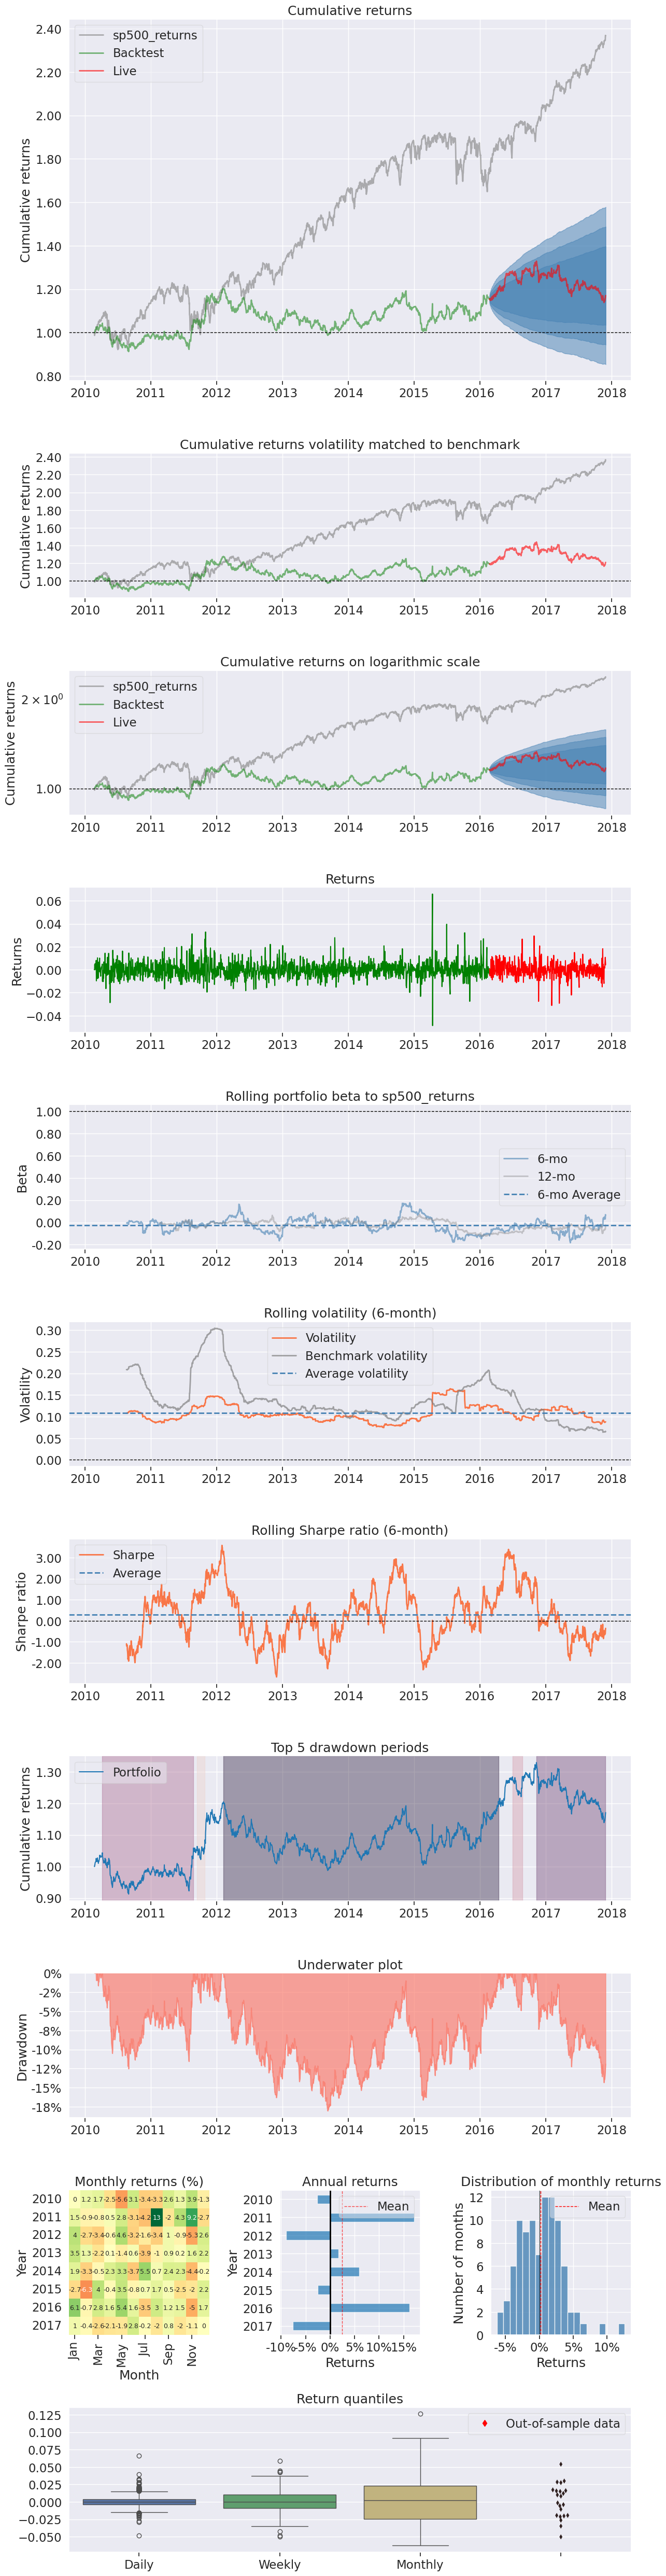

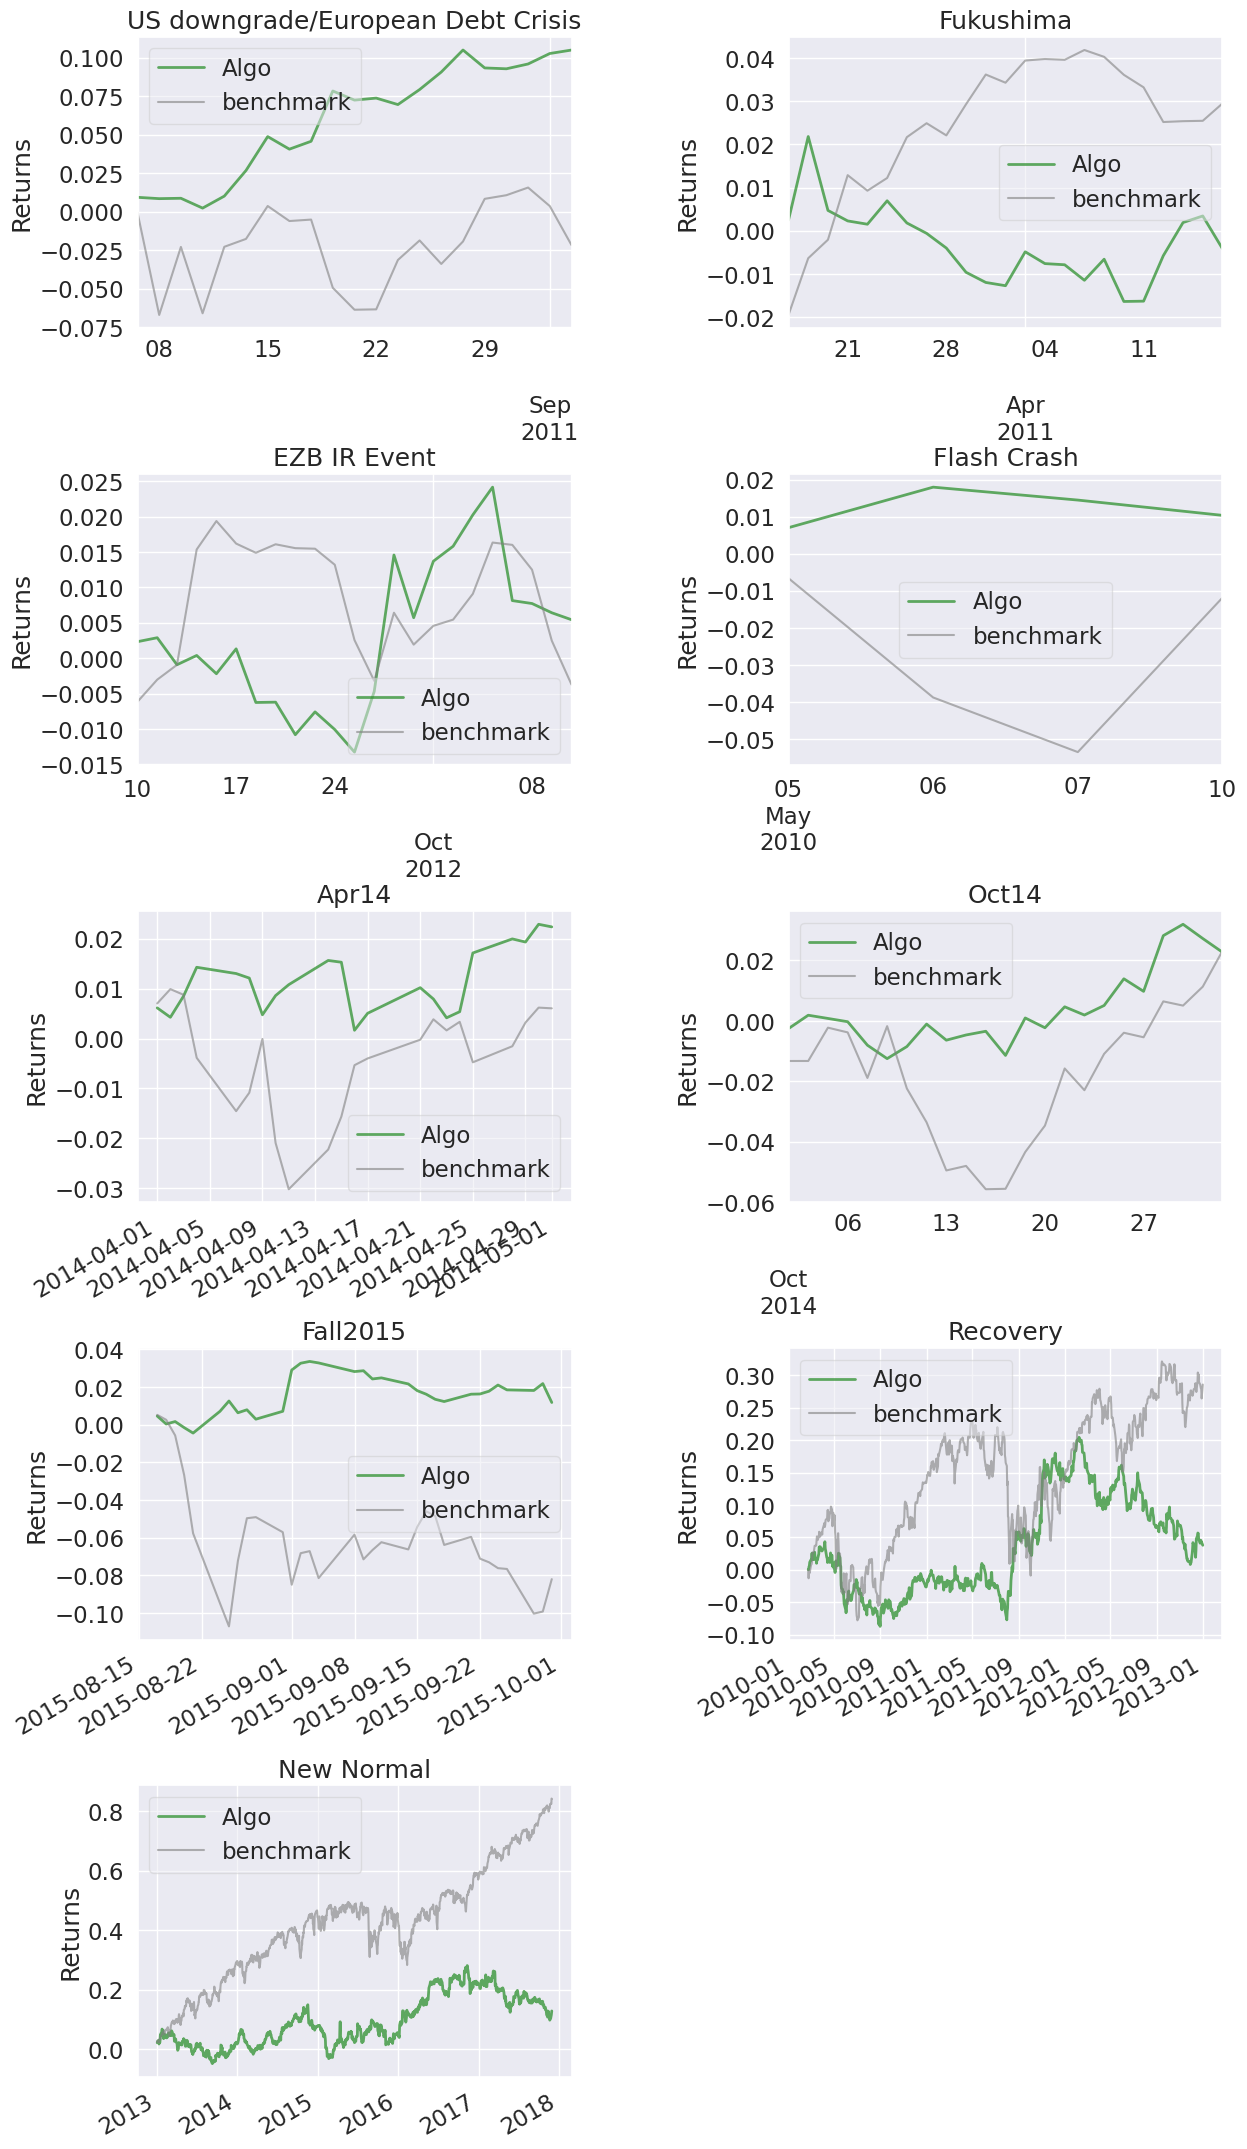

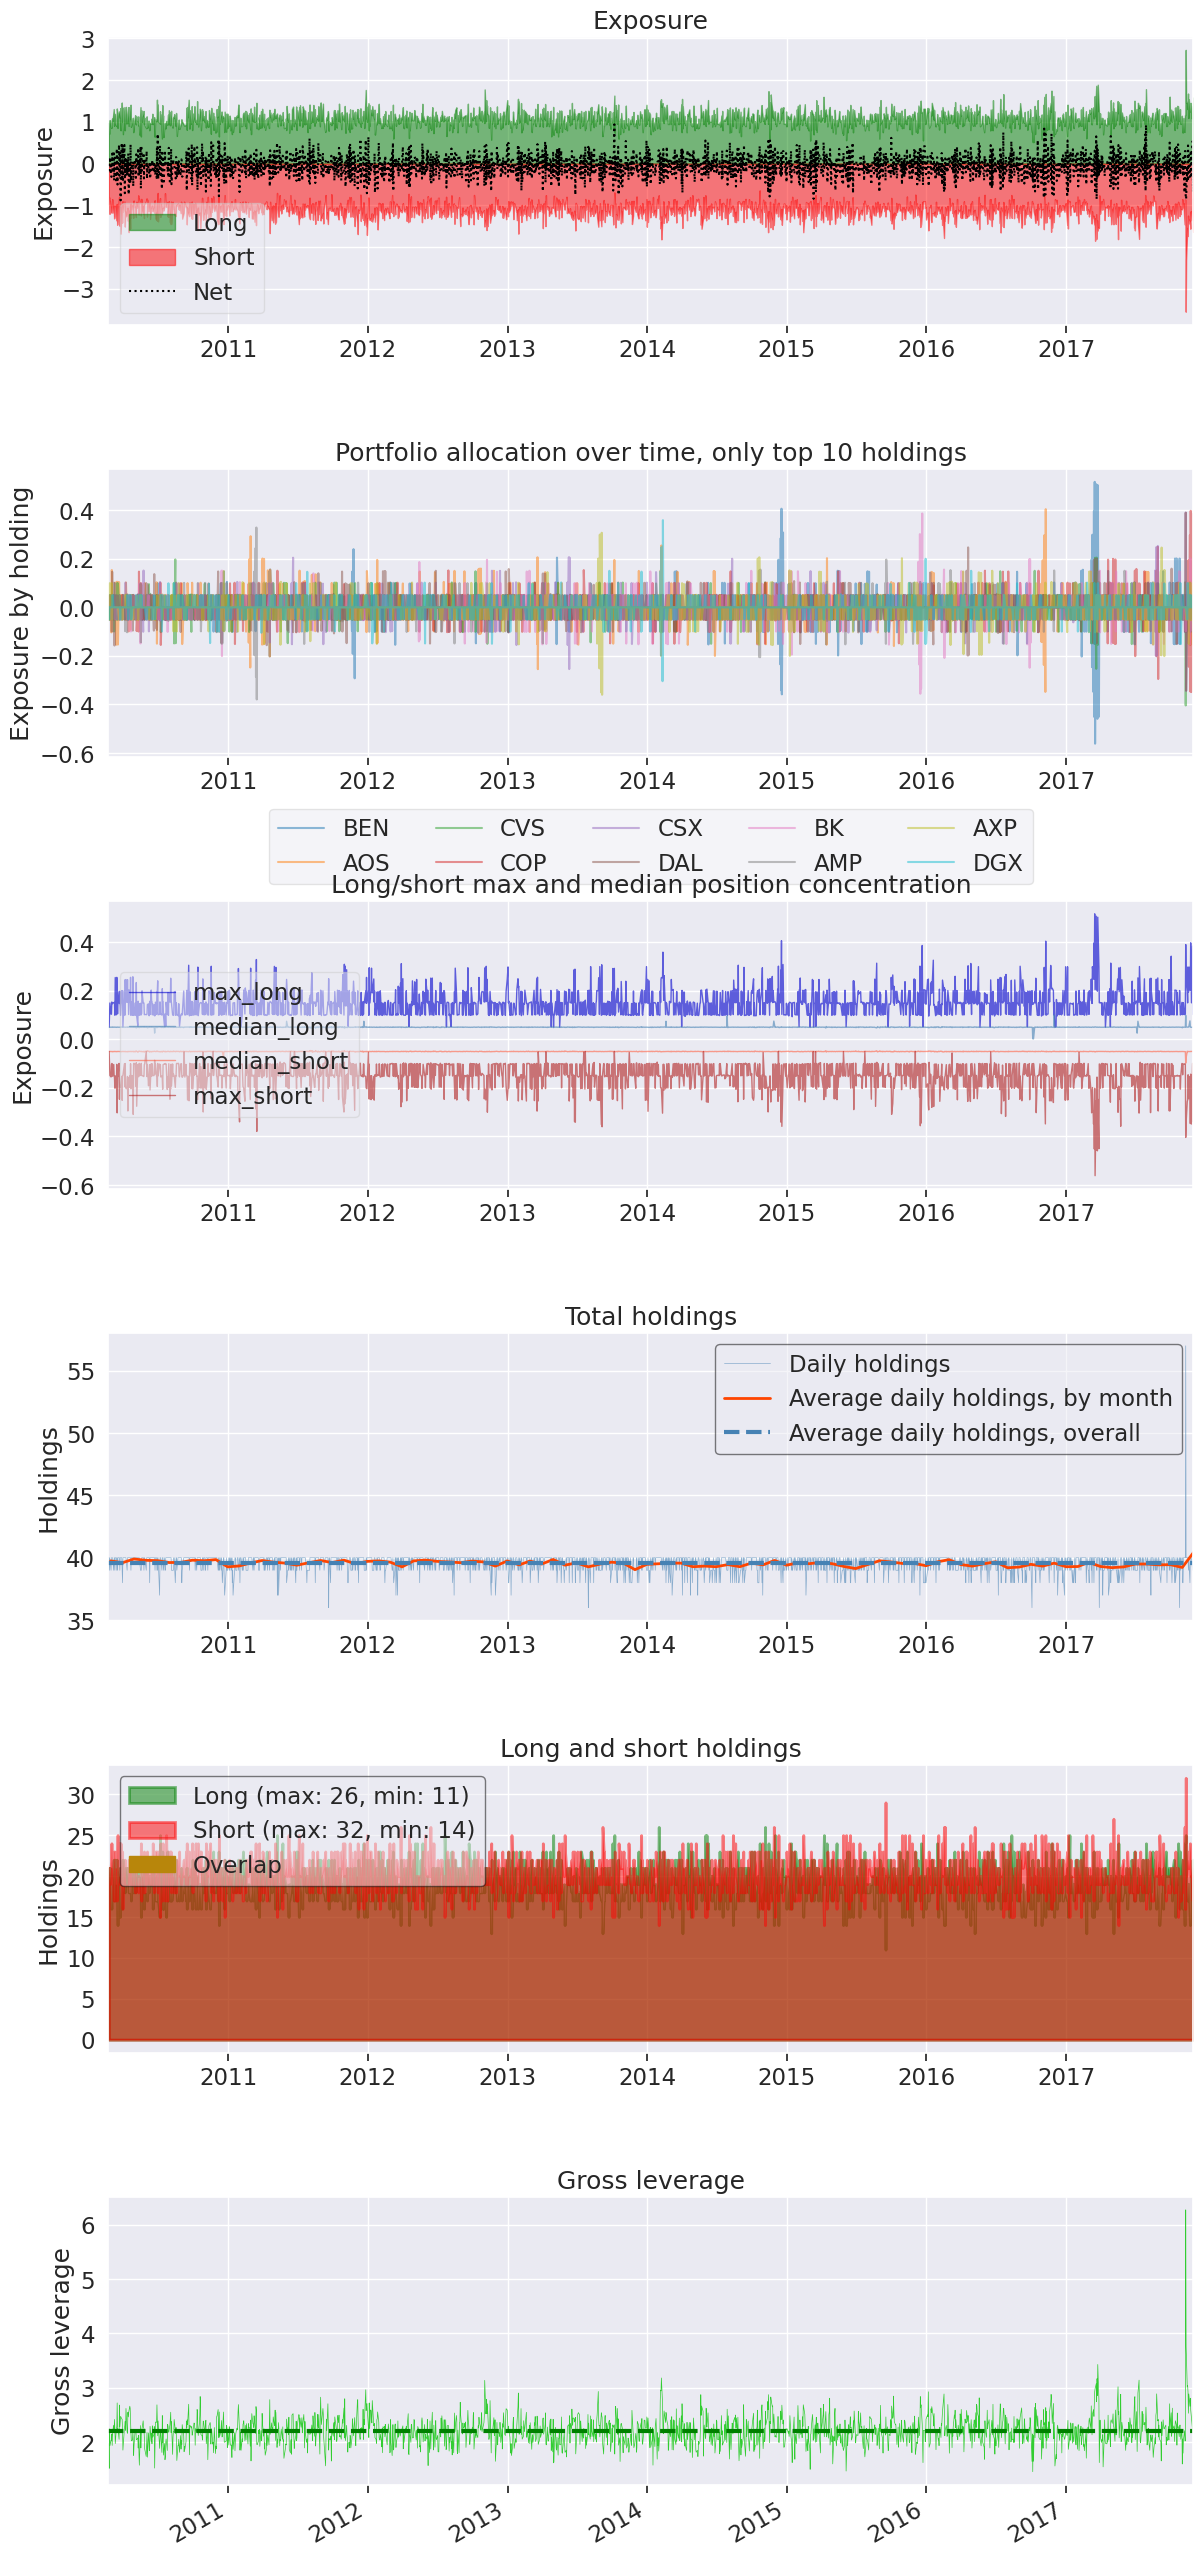

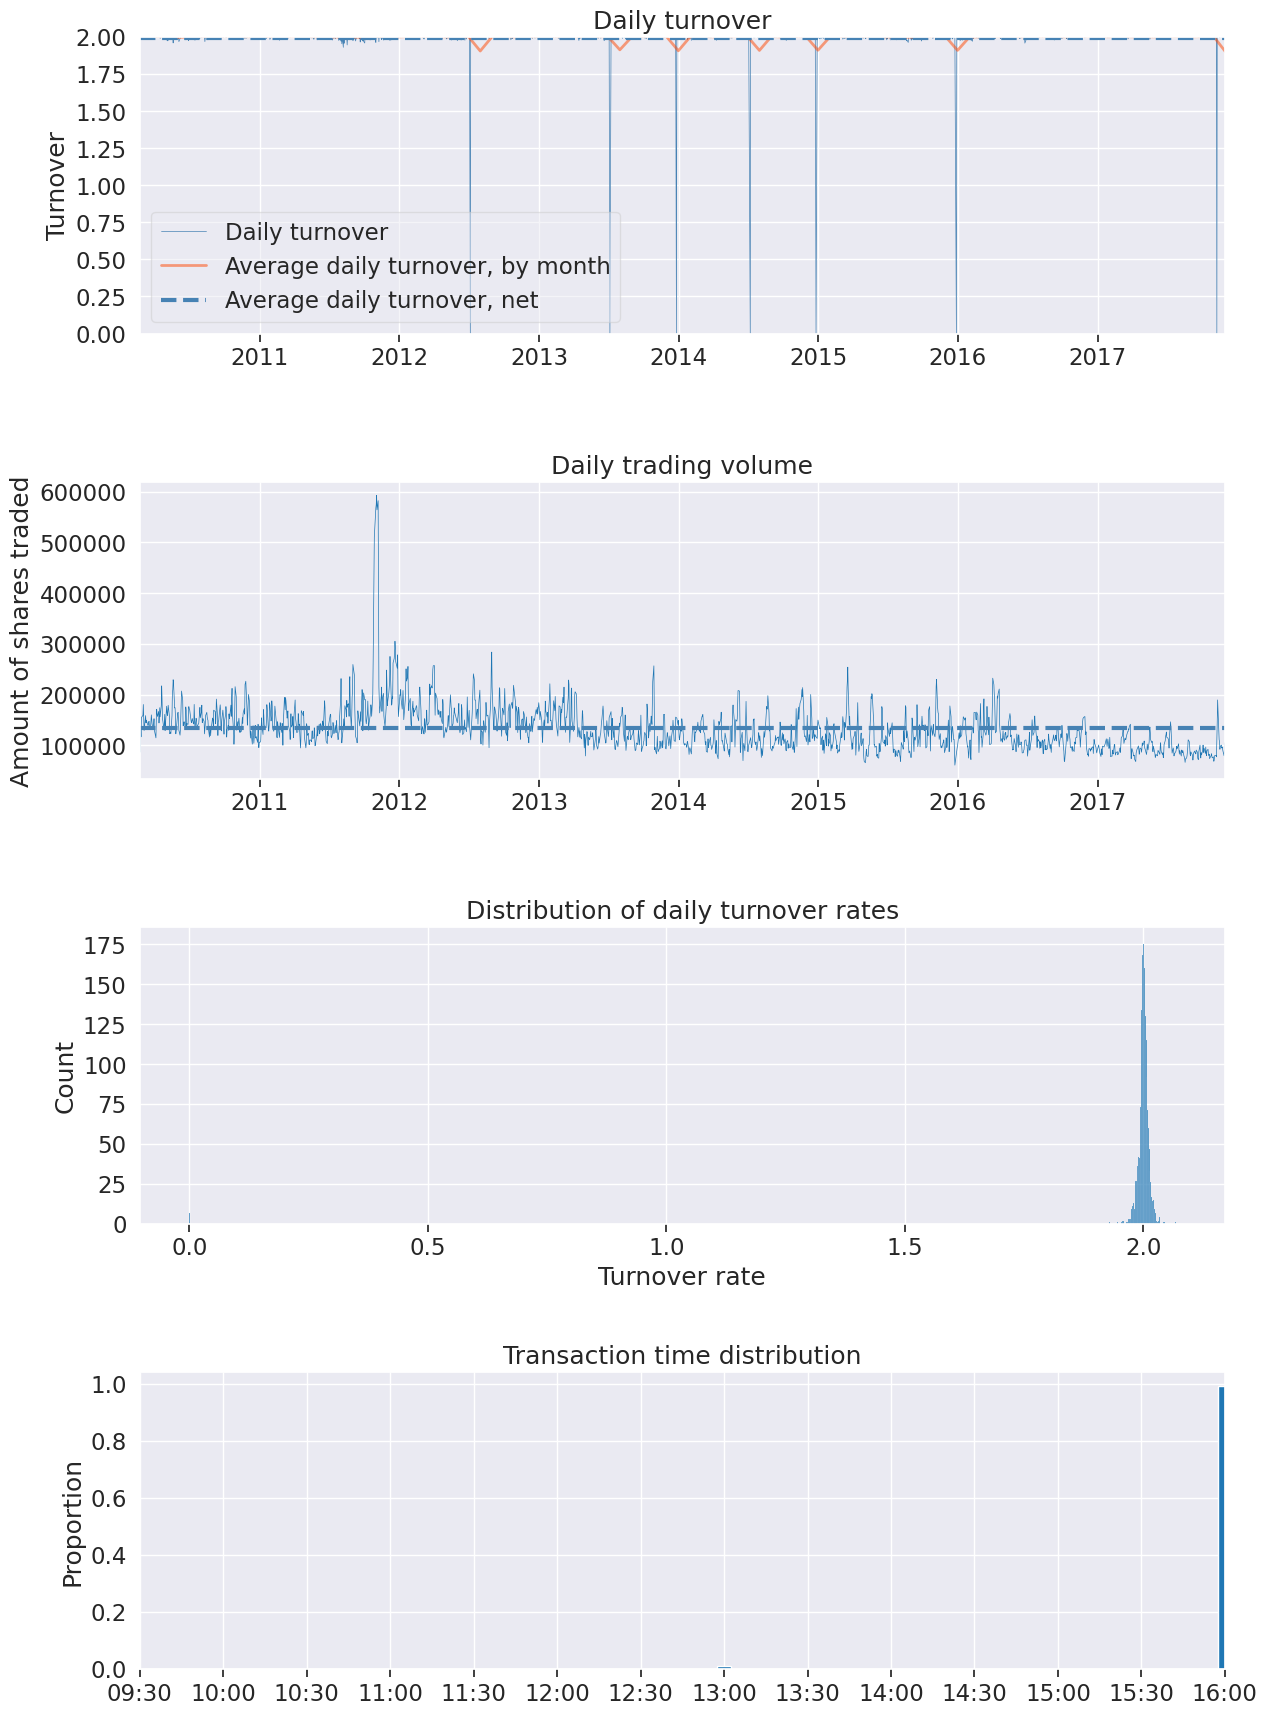

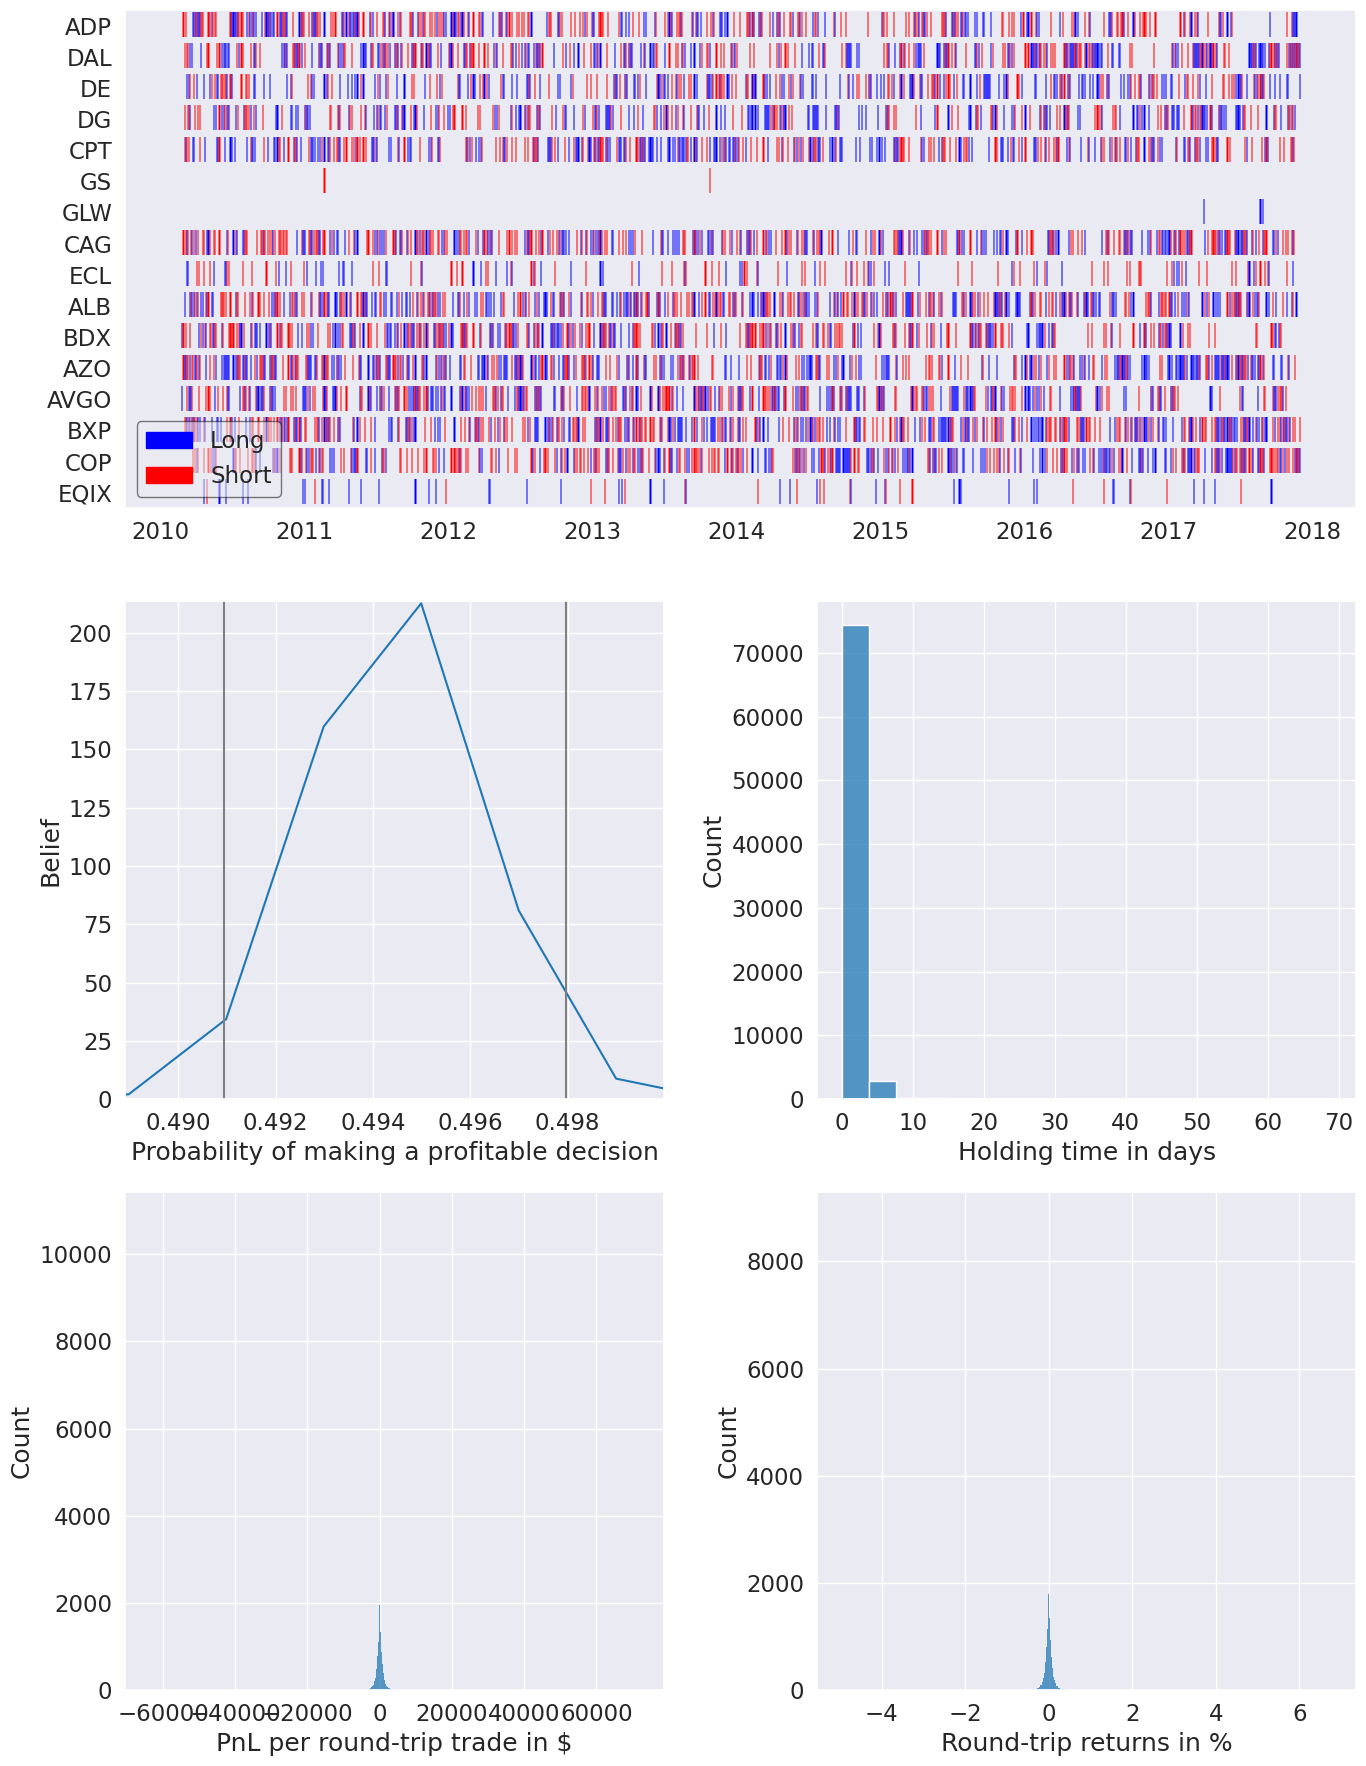

In [21]:
pf.create_full_tear_sheet(
    returns,
    positions=positions,
    transactions=transactions,
    benchmark_rets=benchmark_data,
    live_start_date=LIVE_DATE,
    round_trips=True
)